TITLE : Fantasy Team Selection Using Machine Learning

IMPORT LIBRARIES

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

UPLOAD DATASET

In [4]:
from google.colab import files
uploaded = files.upload()

Saving all_matches_ball_by_ball1.csv to all_matches_ball_by_ball1.csv


LOAD DATA

In [5]:
df = pd.read_csv("all_matches_ball_by_ball1.csv", on_bad_lines='skip', engine='python')
print("Original Rows:", len(df))
df.head()

Original Rows: 83090


,match_id,date,venue,city,batting_team,batter,bowler,over,runs_batter,runs_extras,extras_type,wicket_taken,dismissal_kind,player_out,pitch_type,boundary
0,1216492,19-09-2020,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,RG Sharma,DL Chahar,0,4,0,NaN,0,NaN,NaN,Spin-friendly,4.0
1,1216492,19-09-2020,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,RG Sharma,DL Chahar,0,1,0,NaN,0,NaN,NaN,Spin-friendly,NaN
2,1216492,19-09-2020,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Q de Kock,DL Chahar,0,2,0,NaN,0,NaN,NaN,Spin-friendly,NaN
3,1216492,19-09-2020,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Q de Kock,DL Chahar,0,4,0,NaN,0,NaN,NaN,Spin-friendly,4.0
4,1216492,19-09-2020,Sheikh Zayed Stadium,Abu Dhabi,Mumbai Indians,Q de Kock,DL Chahar,0,0,0,NaN,0,NaN,NaN,Spin-friendly,NaN


DATA CLEANING

In [6]:
print(df.isnull().sum())

df = df.drop_duplicates()

print("After removing duplicates:", len(df))

match_id              0
date                  0
venue                 0
city                  0
batting_team          0
batter                0
bowler                0
over                  0
runs_batter           0
runs_extras           0
extras_type       78433
wicket_taken          0
dismissal_kind    78920
player_out        78920
pitch_type            0
boundary          68408
dtype: int64
After removing duplicates: 61215


FEATURE ENGINEERING

In [7]:
batter_stats = df.groupby("batter").agg({
    "runs_batter": "sum",
    "wicket_taken": "sum",
    "boundary": "count"
}).reset_index()

balls = df.groupby("batter").size().reset_index(name="balls")

batter_stats = batter_stats.merge(balls, on="batter")

batter_stats["strike_rate"] = (
    batter_stats["runs_batter"] / batter_stats["balls"]
) * 100

batter_stats.head()

,batter,runs_batter,wicket_taken,boundary,balls,strike_rate
0,A Badoni,509,27,59,382,133.246073
1,A Kamboj,1,0,0,1,100.000000
2,A Manohar,171,15,23,132,129.545455
3,A Mishra,15,1,2,15,100.000000
4,A Nortje,41,5,5,40,102.500000


Feature Selection

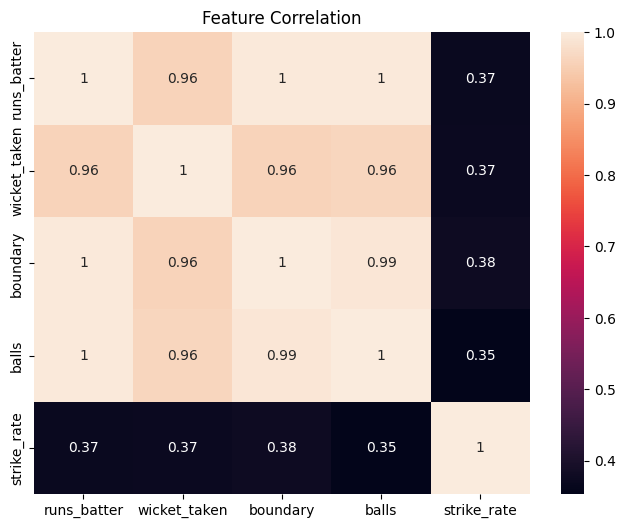

In [8]:
# Correlation-based feature selection
corr = batter_stats.corr(numeric_only=True)

plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)
plt.title("Feature Correlation")
plt.show()

In [9]:
print(batter_stats.columns)

Index(['batter', 'runs_batter', 'wicket_taken', 'boundary', 'balls',
       'strike_rate'],
      dtype='object')


In [10]:
batter_stats["fantasy_points"] = (
    batter_stats["runs_batter"] +
    batter_stats["wicket_taken"] * 25 +
    batter_stats["boundary"] * 4
)
batter_stats.head()

,batter,runs_batter,wicket_taken,boundary,balls,strike_rate,fantasy_points
0,A Badoni,509,27,59,382,133.246073,1420
1,A Kamboj,1,0,0,1,100.000000,1
2,A Manohar,171,15,23,132,129.545455,638
3,A Mishra,15,1,2,15,100.000000,48
4,A Nortje,41,5,5,40,102.500000,186


In [11]:
# Selecting important features manually
selected_features = ["runs_batter", "wicket_taken", "boundary", "balls", "strike_rate"]

X = batter_stats[selected_features]
y = batter_stats["fantasy_points"]

Encoding

In [12]:

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
batter_stats["batter_encoded"] = le.fit_transform(batter_stats["batter"])
batter_stats.head()

,batter,runs_batter,wicket_taken,boundary,balls,strike_rate,fantasy_points,batter_encoded
0,A Badoni,509,27,59,382,133.246073,1420,0
1,A Kamboj,1,0,0,1,100.000000,1,1
2,A Manohar,171,15,23,132,129.545455,638,2
3,A Mishra,15,1,2,15,100.000000,48,3
4,A Nortje,41,5,5,40,102.500000,186,4


In [13]:
X = batter_stats.drop(columns=["batter", "batter_encoded", "fantasy_points"])

Download the File :Save the Updated Dataset

In [14]:
batter_stats.to_csv("processed_player_stats.csv", index=False)

print("File saved successfully!")


File saved successfully!


In [15]:
from google.colab import files

files.download("processed_player_stats.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

TARGET VARIABLE

In [16]:
batter_stats["fantasy_points"] = (
    batter_stats["runs_batter"] +
    batter_stats["wicket_taken"] * 25 +
    batter_stats["boundary"] * 4
)

batter_stats.head()

,batter,runs_batter,wicket_taken,boundary,balls,strike_rate,fantasy_points,batter_encoded
0,A Badoni,509,27,59,382,133.246073,1420,0
1,A Kamboj,1,0,0,1,100.000000,1,1
2,A Manohar,171,15,23,132,129.545455,638,2
3,A Mishra,15,1,2,15,100.000000,48,3
4,A Nortje,41,5,5,40,102.500000,186,4


SAVE DATASET

In [17]:
batter_stats.to_csv("processed_player_stats.csv", index=False)
print("Saved successfully!")

Saved successfully!


VISUALIZATION

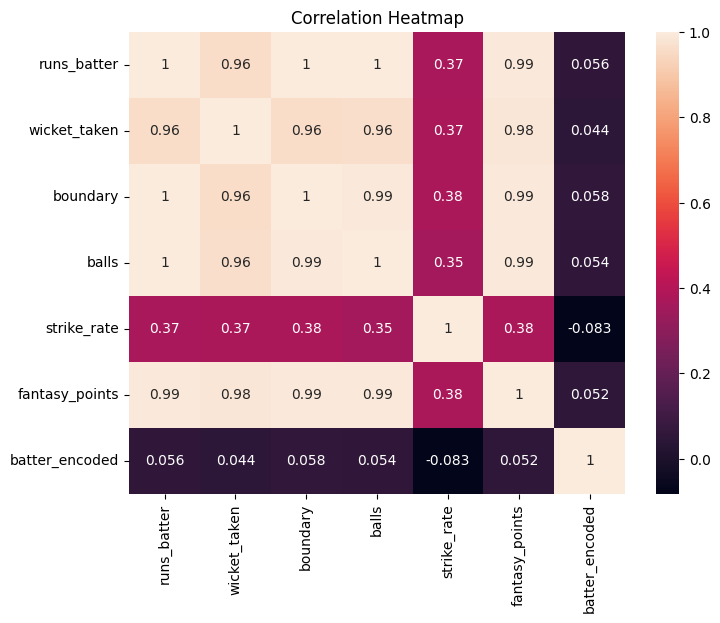

In [18]:
plt.figure(figsize=(8,6))
sns.heatmap(batter_stats.corr(numeric_only=True), annot=True)
plt.title("Correlation Heatmap")
plt.show()

SCATTER PLOT

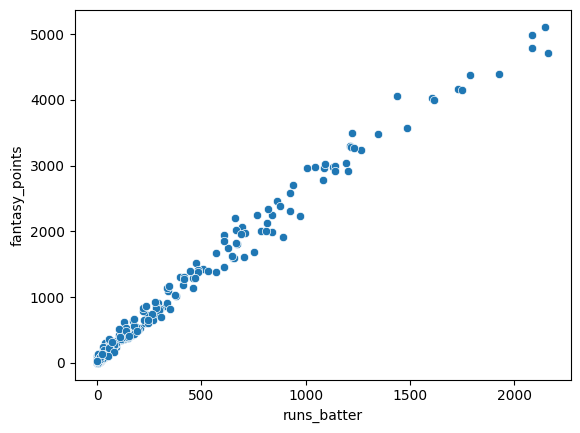

In [19]:
sns.scatterplot(x='runs_batter', y='fantasy_points', data=batter_stats)
plt.show()

PREPARE DATA

In [20]:
X = batter_stats.drop(columns=["batter", "fantasy_points"])
y = batter_stats["fantasy_points"]

TRAIN TEST SPLIT

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

Standardization

In [22]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

Feature Scaling

In [23]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

LINEAR REGRESSION

In [24]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)


print("Linear Regression")
print("MAE:", mean_absolute_error(y_test, y_pred_lr))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_lr)))
print("R2:", r2_score(y_test, y_pred_lr))

Linear Regression
MAE: 6.244163435467547e-13
RMSE: 9.130673131124965e-13
R2: 1.0


KNN Regressor

In [25]:
from sklearn.neighbors import KNeighborsRegressor

knn = KNeighborsRegressor(n_neighbors=5)

knn.fit(X_train_scaled, y_train)

y_pred_knn = knn.predict(X_test_scaled)

print("\n🔹 KNN Regressor")
print("MAE:", mean_absolute_error(y_test, y_pred_knn))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_knn)))
print("R2:", r2_score(y_test, y_pred_knn))


🔹 KNN Regressor
MAE: 78.56363636363636
RMSE: 139.1405524400896
R2: 0.9849880592884701


DECISION TREE

In [26]:
from sklearn.tree import DecisionTreeRegressor

dt = DecisionTreeRegressor(random_state=42)
dt.fit(X_train, y_train)

y_pred_dt = dt.predict(X_test)

print("Decision Tree")
print("MAE:", mean_absolute_error(y_test, y_pred_dt))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_dt)))
print("R2:", r2_score(y_test, y_pred_dt))

Decision Tree
MAE: 60.31818181818182
RMSE: 122.32241302096982
R2: 0.9883977699283518


RANDOM FOREST

In [27]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

y_pred_rf = rf.predict(X_test)

print("Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_rf)))
print("R2:", r2_score(y_test, y_pred_rf))

Random Forest
MAE: 31.375909090909083
RMSE: 79.6920605813212
R2: 0.9950755298790387


Hyperparameter Tuning

In [28]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(
    RandomForestRegressor(random_state=42),
    param_grid,
    cv=3,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


In [1]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor, AdaBoostRegressor
from sklearn.ensemble import ExtraTreesRegressor

AdaBoost


In [29]:
ab = AdaBoostRegressor(n_estimators=100, random_state=42)
ab.fit(X_train, y_train)

y_pred_ab = ab.predict(X_test)

Gradient Boosting Model

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor

gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

print("\n🔹 Gradient Boosting")
print("MAE:", mean_absolute_error(y_test, y_pred_gb))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_gb)))
print("R2:", r2_score(y_test, y_pred_gb))


🔹 Gradient Boosting
MAE: 28.95760680872771
RMSE: 65.51282112418296
R2: 0.9966720101210134


In [32]:
gb = GradientBoostingRegressor(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)

EXTRATREES

In [30]:
et = ExtraTreesRegressor(n_estimators=100, random_state=42)
et.fit(X_train, y_train)

y_pred_et = et.predict(X_test)

EVALUATION

In [33]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

def evaluate_model(name, y_test, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_test, y_pred))
    print("MSE:", mean_squared_error(y_test, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
    print("R2 Score:", r2_score(y_test, y_pred))

evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("AdaBoost", y_test, y_pred_ab)
evaluate_model("Extra Trees", y_test, y_pred_et)


Random Forest
MAE: 31.375909090909083
MSE: 6350.824519696969
RMSE: 79.6920605813212
R2 Score: 0.9950755298790387

Gradient Boosting
MAE: 28.95760680872771
MSE: 4291.929731649194
RMSE: 65.51282112418296
R2 Score: 0.9966720101210134

AdaBoost
MAE: 86.78532958452386
MSE: 14343.409046383644
RMSE: 119.76397223866468
R2 Score: 0.9888780285043978

Extra Trees
MAE: 22.84848484848485
MSE: 4123.020593939396
RMSE: 64.21075138899558
R2 Score: 0.9968029833512183


COMPARISON TABLE

In [34]:
import pandas as pd

results = pd.DataFrame({
    "Model": ["Random Forest", "Gradient Boosting", "AdaBoost", "Extra Trees"],
    "MAE": [
        mean_absolute_error(y_test, y_pred_rf),
        mean_absolute_error(y_test, y_pred_gb),
        mean_absolute_error(y_test, y_pred_ab),
        mean_absolute_error(y_test, y_pred_et)
    ],
    "RMSE": [
        np.sqrt(mean_squared_error(y_test, y_pred_rf)),
        np.sqrt(mean_squared_error(y_test, y_pred_gb)),
        np.sqrt(mean_squared_error(y_test, y_pred_ab)),
        np.sqrt(mean_squared_error(y_test, y_pred_et))
    ],
    "R2 Score": [
        r2_score(y_test, y_pred_rf),
        r2_score(y_test, y_pred_gb),
        r2_score(y_test, y_pred_ab),
        r2_score(y_test, y_pred_et)
    ]
})

results

,Model,MAE,RMSE,R2 Score
0,Random Forest,31.375909,79.692061,0.995076
1,Gradient Boosting,28.957607,65.512821,0.996672
2,AdaBoost,86.785330,119.763972,0.988878
3,Extra Trees,22.848485,64.210751,0.996803


BAR  GRAPH

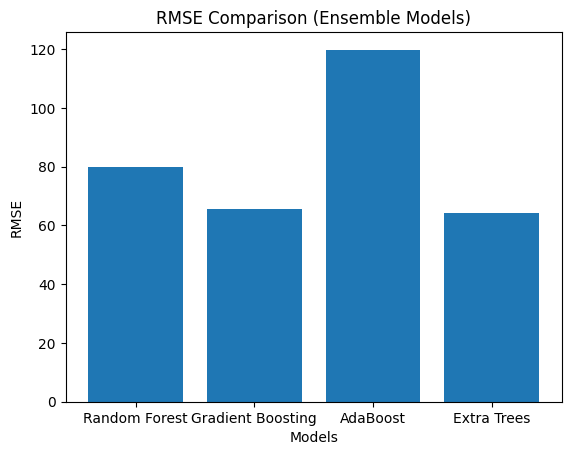

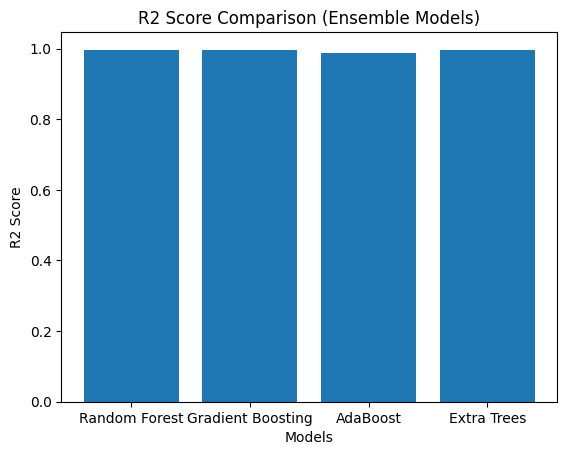

In [35]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(results["Model"], results["RMSE"])
plt.title("RMSE Comparison (Ensemble Models)")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.show()

plt.figure()
plt.bar(results["Model"], results["R2 Score"])
plt.title("R2 Score Comparison (Ensemble Models)")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

MODEL COMPARISON GRAPH

Use Tuned Model

In [ ]:
y_pred_best_rf = best_rf.predict(X_test)

print("\n🔹 Tuned Random Forest")
print("MAE:", mean_absolute_error(y_test, y_pred_best_rf))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred_best_rf)))
print("R2:", r2_score(y_test, y_pred_best_rf))


🔹 Tuned Random Forest
MAE: 29.926060606060613
RMSE: 71.39864976229445
R2: 0.9960471585819343


In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

models = ['Linear Regression', 'KNN', 'Decision Tree', 'Random Forest']

# MAE
mae_values = [
    mean_absolute_error(y_test, y_pred_lr),
    mean_absolute_error(y_test, y_pred_knn),
    mean_absolute_error(y_test, y_pred_dt),
    mean_absolute_error(y_test, y_pred_rf)
]

# MSE
mse_values = [
    mean_squared_error(y_test, y_pred_lr),
    mean_squared_error(y_test, y_pred_knn),
    mean_squared_error(y_test, y_pred_dt),
    mean_squared_error(y_test, y_pred_rf)
]

# RMSE
rmse_values = [
    np.sqrt(mean_squared_error(y_test, y_pred_lr)),
    np.sqrt(mean_squared_error(y_test, y_pred_knn)),
    np.sqrt(mean_squared_error(y_test, y_pred_dt)),
    np.sqrt(mean_squared_error(y_test, y_pred_rf))
]

# R2
r2_values = [
    r2_score(y_test, y_pred_lr),
    r2_score(y_test, y_pred_knn),
    r2_score(y_test, y_pred_dt),
    r2_score(y_test, y_pred_rf)
]

In [ ]:
models = [
    'Linear Regression',
    'KNN',
    'Decision Tree',
    'Random Forest',
    'Gradient Boosting',
    'Tuned Random Forest'
]

MAE GRAPH

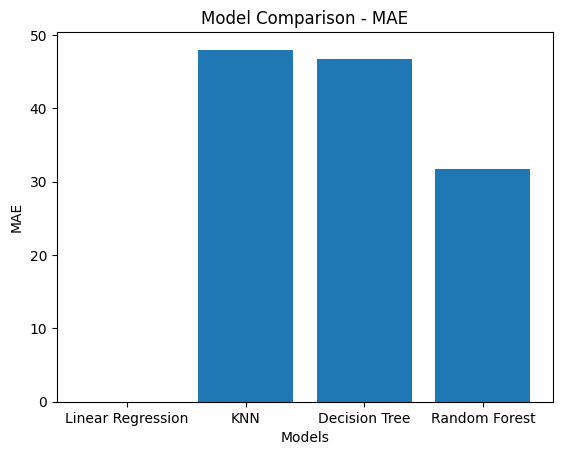

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.bar(models, mae_values)
plt.title("Model Comparison - MAE")
plt.xlabel("Models")
plt.ylabel("MAE")
plt.show()

RMSE Comparison Graph

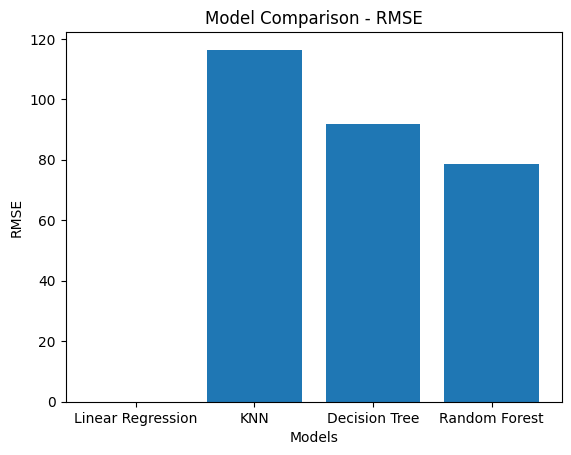

In [ ]:
plt.figure()
plt.bar(models, rmse_values)
plt.title("Model Comparison - RMSE")
plt.xlabel("Models")
plt.ylabel("RMSE")
plt.show()

MSE Comparison Graph

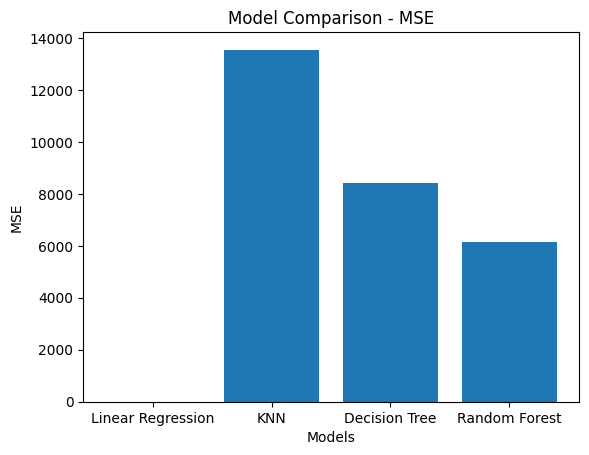

In [ ]:
plt.figure()
plt.bar(models, mse_values)
plt.title("Model Comparison - MSE")
plt.xlabel("Models")
plt.ylabel("MSE")
plt.show()

R2 GRAPH

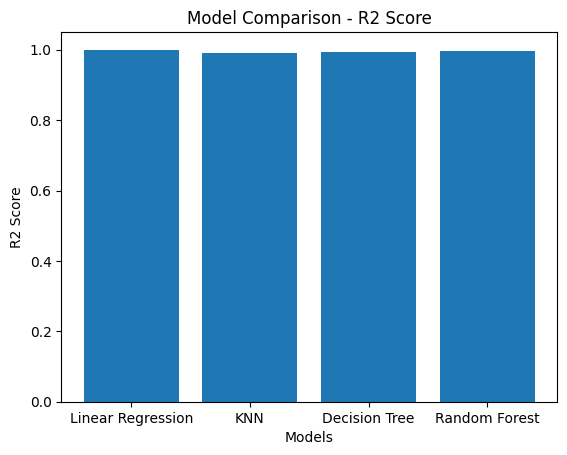

In [ ]:
plt.figure()
plt.bar(models, r2_values)
plt.title("Model Comparison - R2 Score")
plt.xlabel("Models")
plt.ylabel("R2 Score")
plt.show()

Actual vs Predicted (Random Forest)

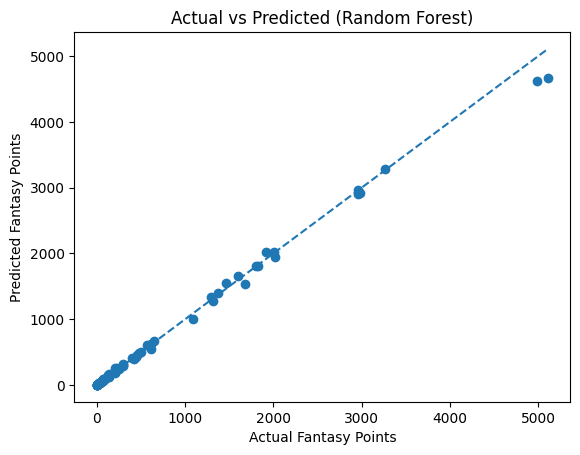

In [ ]:
plt.figure()
plt.scatter(y_test, y_pred_rf)

# Ideal line
plt.plot([y_test.min(), y_test.max()],
         [y_test.min(), y_test.max()],
         linestyle='--')

plt.xlabel("Actual Fantasy Points")
plt.ylabel("Predicted Fantasy Points")
plt.title("Actual vs Predicted (Random Forest)")
plt.show()

Error Distribution (Random Forest)

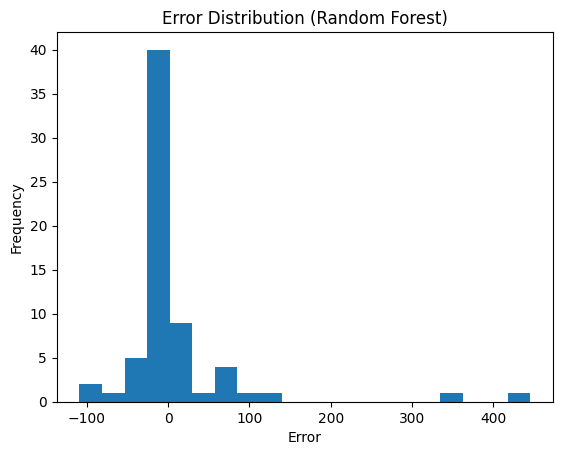

In [ ]:
errors = y_test - y_pred_rf

plt.figure()
plt.hist(errors, bins=20)
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.title("Error Distribution (Random Forest)")
plt.show()

SAVE MODEL RESULTS

In [ ]:
import pandas as pd

results = pd.DataFrame({
    "Model": models,
    "MAE": mae_values,
    "MSE": mse_values,
    "RMSE": rmse_values,
    "R2": r2_values
})

results.to_csv("model_comparison_results.csv", index=False)

results

,Model,MAE,MSE,RMSE,R2
0,Linear Regression,7.751375e-14,2.252031e-26,1.500677e-13,1.000000
1,KNN,4.800909e+01,1.354678e+04,1.163906e+02,0.989496
2,Decision Tree,4.675758e+01,8.429515e+03,9.181239e+01,0.993464
3,Random Forest,3.179379e+01,6.163997e+03,7.851113e+01,0.995220


DOWNLOAD FILES

In [ ]:
from google.colab import files

files.download("processed_player_stats.csv")
files.download("model_comparison_results.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Gradient Boosting Model

In [ ]:
gb = GradientBoostingRegressor(random_state=42)

gb.fit(X_train, y_train)

GradientBoostingRegressor(random_state=42)

Hyperparameter Tuning (Random Forest)

In [ ]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [None, 10],
    'min_samples_split': [2, 5]
}

grid = GridSearchCV(RandomForestRegressor(random_state=42),
                    param_grid,
                    cv=3,
                    scoring='r2',
                    n_jobs=-1)

grid.fit(X_train, y_train)

best_rf = grid.best_estimator_

print("Best Parameters:", grid.best_params_)

Best Parameters: {'max_depth': None, 'min_samples_split': 2, 'n_estimators': 50}


Predictions

In [ ]:
y_pred_lr = lr.predict(X_test_scaled)
y_pred_knn = knn.predict(X_test_scaled)
y_pred_dt = dt.predict(X_test)
y_pred_rf = rf.predict(X_test)
y_pred_gb = gb.predict(X_test)
y_pred_best_rf = best_rf.predict(X_test)

Evaluation Function

In [ ]:
def evaluate_model(name, y_true, y_pred):
    print(f"\n{name}")
    print("MAE:", mean_absolute_error(y_true, y_pred))
    print("MSE:", mean_squared_error(y_true, y_pred))
    print("RMSE:", np.sqrt(mean_squared_error(y_true, y_pred)))
    print("R2:", r2_score(y_true, y_pred))

Evaluate All Models

In [ ]:
evaluate_model("Linear Regression", y_test, y_pred_lr)
evaluate_model("KNN", y_test, y_pred_knn)
evaluate_model("Decision Tree", y_test, y_pred_dt)
evaluate_model("Random Forest", y_test, y_pred_rf)
evaluate_model("Gradient Boosting", y_test, y_pred_gb)
evaluate_model("Tuned Random Forest", y_test, y_pred_best_rf)


Linear Regression
MAE: 6.244163435467547e-13
MSE: 8.336919182744737e-25
RMSE: 9.130673131124965e-13
R2: 1.0

KNN
MAE: 78.56363636363636
MSE: 19360.093333333323
RMSE: 139.1405524400896
R2: 0.9849880592884701

Decision Tree
MAE: 60.31818181818182
MSE: 14962.772727272728
RMSE: 122.32241302096982
R2: 0.9883977699283518

Random Forest
MAE: 31.375909090909083
MSE: 6350.824519696969
RMSE: 79.6920605813212
R2: 0.9950755298790387

Gradient Boosting
MAE: 28.95760680872771
MSE: 4291.929731649194
RMSE: 65.51282112418296
R2: 0.9966720101210134

Tuned Random Forest
MAE: 29.926060606060613
MSE: 5097.76718787879
RMSE: 71.39864976229445
R2: 0.9960471585819343


Cross Validation

In [ ]:
from sklearn.model_selection import cross_val_score
models = {
    "LR": lr,
    "KNN": knn,
    "DT": dt,
    "RF": rf
}

for name, model in models.items():
    scores = cross_val_score(model, X, y, cv=5, scoring='r2')
    print(f"{name} Avg R2:", scores.mean())

LR Avg R2: 1.0
KNN Avg R2: 0.9868786488086133
DT Avg R2: 0.9865058052645516
RF Avg R2: 0.9961116773738421


FINAL ML MODEL

In [ ]:
final_model = best_rf

final_model.fit(X_train, y_train)

y_pred_ml = final_model.predict(X_test)

Final ML Evaluation

In [ ]:
evaluate_model("Final ML Model", y_test, y_pred_ml)


Final ML Model
MAE: 29.926060606060613
MSE: 5097.76718787879
RMSE: 71.39864976229445
R2: 0.9960471585819343


Deep Learning Model

In [ ]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train_scaled.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse', metrics=['mae'])

history = model.fit(X_train_scaled, y_train,
                    epochs=50,
                    batch_size=16,
                    validation_split=0.2)

Epoch 1/50


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 1688908.5000 - mae: 707.2000 - val_loss: 1774593.5000 - val_mae: 792.1722
Epoch 2/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 1687652.0000 - mae: 706.5900 - val_loss: 1773248.0000 - val_mae: 791.5907
Epoch 3/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1686224.0000 - mae: 705.9382 - val_loss: 1771623.3750 - val_mae: 790.9303
Epoch 4/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 1684493.5000 - mae: 705.1470 - val_loss: 1769320.1250 - val_mae: 790.0434
Epoch 5/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1681707.1250 - mae: 704.0820 - val_loss: 1765891.1250 - val_mae: 788.8661
Epoch 6/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1678092.0000 - mae: 702.6824 - val_loss: 1761104.8750 - val_mae: 787.2625
Epoch 7/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1672790.8750 - mae: 700.8478 - val_loss: 1754833.7500 - val_mae: 785.1884
Epoch 8/50
13/13 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 1666080.8750 - mae: 698.5714

DL Prediction & Evaluation

In [ ]:
y_pred_dl = model.predict(X_test_scaled).flatten()

evaluate_model("Deep Learning Model", y_test, y_pred_dl)

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step

Deep Learning Model
MAE: 88.6308364868164
MSE: 12806.1875
RMSE: 113.1644268310497
R2: 0.9900699853897095


Final Comparison

In [ ]:
print("\nFinal Comparison")

print("ML R2:", r2_score(y_test, y_pred_ml))
print("DL R2:", r2_score(y_test, y_pred_dl))


Final Comparison
ML R2: 0.9960471585819343
DL R2: 0.9900699853897095


Fantasy Team Selection

In [ ]:
batter_stats["predicted_points"] = final_model.predict(X)

team = batter_stats.sort_values(by="predicted_points", ascending=False)

fantasy_team = team.head(11)

print("\n🏏 Recommended Fantasy Team:")
print(fantasy_team[["batter", "predicted_points"]])


🏏 Recommended Fantasy Team:
           batter  predicted_points
78   F du Plessis           4694.94
284  Shubman Gill           4685.30
306       V Kohli           4684.80
131      KL Rahul           4646.42
228    RD Gaikwad           4386.10
271     SV Samson           4308.24
246      S Dhawan           4193.20
106    JC Buttler           4150.62
100  Ishan Kishan           4028.12
252      SA Yadav           4009.24
230     RG Sharma           3899.22


Save Output CSV

In [ ]:
batter_stats.to_csv("final_fantasy_team.csv", index=False)

In [ ]:
# Save predictions table (optional)
batter_stats.to_csv("final_fantasy_team.csv", index=False)

# Save model comparison (optional)
# (create a small dataframe if you haven't already)

In [ ]:
from google.colab import files
files.download("final_fantasy_team.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>